# Interior: daylight factor and energy balance (Beta)

**Question:** how much daylight reaches the rooms of a small building, and how much heating
and cooling do the rooms need over one year?

The building has two floors and two rooms on each floor: a room to the south with large
windows and a room to the north with small windows. A 15 m high block stands across the
street to the south. It takes light and winter sun from the lower floor.

**Steps**
1. Make the walls, slabs, windows and room volumes (meshes in metres).
2. Check the model in 3D.
3. Run the daylight factor for each floor, and draw a floor plan.
4. Run the energy balance with the `"irradiance"` solar model (it uses the shade of the neighbour).
5. Show the monthly heating and cooling need.

Both interior models are **Beta**. They do not run as an area run: use `client.analyses.run_and_wait`.
Docs: [Interior](https://infrared.city/docs/sdk/#interior-beta).

In [1]:
import logging
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image

from infrared_sdk import (DaylightFactorModelRequest, EnergyBalanceModelRequest, InfraredClient,
                          interior_entities, parse_epw)
from infrared_sdk.analyses.types import AnalysesName

import ir_site as site
import ir_view3d as v3

os.environ.setdefault("INFRARED_QUIET", "1")  # no SDK progress lines in the notebook
logging.getLogger("infrared_sdk.sdk").setLevel(logging.ERROR)  # no "default base URL" note
# The neighbour block is a plain mesh: the SDK uses the identity position and says so.
warnings.filterwarnings("ignore", message=".*context element has no")
client = InfraredClient()  # reads INFRARED_API_KEY
OUT = Path("outputs")

## 1. The model

Each part is a mesh `{coordinates, indices}` in metres (x east, y north, z up).
- **Barriers:** walls (`category="wall"`) and slabs, the roof too (`category="floor"`).
  The floors of the daylight factor come from the slabs.
- **Openings:** windows (`category="window"`), 1 cm inside the wall plane. `opening_factor` is
  the light transmittance of the glass.
- **Spatial volumes:** one closed box for each room (`category="space"`). They give results for each room.
- **Context:** the neighbour block. It only gives shade.

In [2]:
X0, Y0 = 20.0, 20.0            # south-west corner of the building
W, D, H, FLOORS = 12.0, 8.0, 3.0, 2
E = 0.01                       # windows sit 1 cm inside the wall


def quad(*corners):
    """A flat rectangle from four corners (two triangles)."""
    return {"coordinates": [c for p in corners for c in p], "indices": [0, 1, 2, 0, 2, 3]}


def wall(x0, y0, x1, y1, z0, z1):
    return quad((x0, y0, z0), (x1, y1, z0), (x1, y1, z1), (x0, y0, z1))


walls, slabs, windows, rooms = {}, {}, {}, {}
for k in range(FLOORS + 1):
    z = k * H
    slabs[f"slab-{k}"] = quad((X0, Y0, z), (X0 + W, Y0, z), (X0 + W, Y0 + D, z), (X0, Y0 + D, z))
for k in range(FLOORS):
    z0, z1 = k * H, (k + 1) * H
    walls[f"south-{k}"] = wall(X0, Y0, X0 + W, Y0, z0, z1)
    walls[f"north-{k}"] = wall(X0, Y0 + D, X0 + W, Y0 + D, z0, z1)
    walls[f"west-{k}"] = wall(X0, Y0, X0, Y0 + D, z0, z1)
    walls[f"east-{k}"] = wall(X0 + W, Y0, X0 + W, Y0 + D, z0, z1)
    walls[f"middle-{k}"] = wall(X0, Y0 + D / 2, X0 + W, Y0 + D / 2, z0, z1)  # between the rooms
    for i, xc in enumerate((X0 + 3, X0 + 9)):
        windows[f"south-{k}{i}"] = wall(xc - 1.25, Y0 + E, xc + 1.25, Y0 + E, z0 + 0.8, z0 + 2.6)
        windows[f"north-{k}{i}"] = wall(xc - 0.6, Y0 + D - E, xc + 0.6, Y0 + D - E, z0 + 1.0, z0 + 2.2)
    rooms[f"F{k} south"] = site.box(X0, Y0, X0 + W, Y0 + D / 2, z0, z1)
    rooms[f"F{k} north"] = site.box(X0, Y0 + D / 2, X0 + W, Y0 + D, z0, z1)
neighbour = {"block-south": site.box(X0 - 10, Y0 - 24, X0 + W + 10, Y0 - 14, 0, 15)}

barriers = {**interior_entities(walls, category="wall"), **interior_entities(slabs, category="floor")}
openings = interior_entities(windows, category="window", opening_factor=0.7)
spaces = interior_entities(rooms, category="space")
context = interior_entities(neighbour)
print(f"{len(walls)} walls, {len(slabs)} slabs, {len(windows)} windows, {len(rooms)} rooms")

10 walls, 3 slabs, 8 windows, 4 rooms


## 2. Check the model

Look at the model before you pay: windows in the right walls, the neighbour to the south.

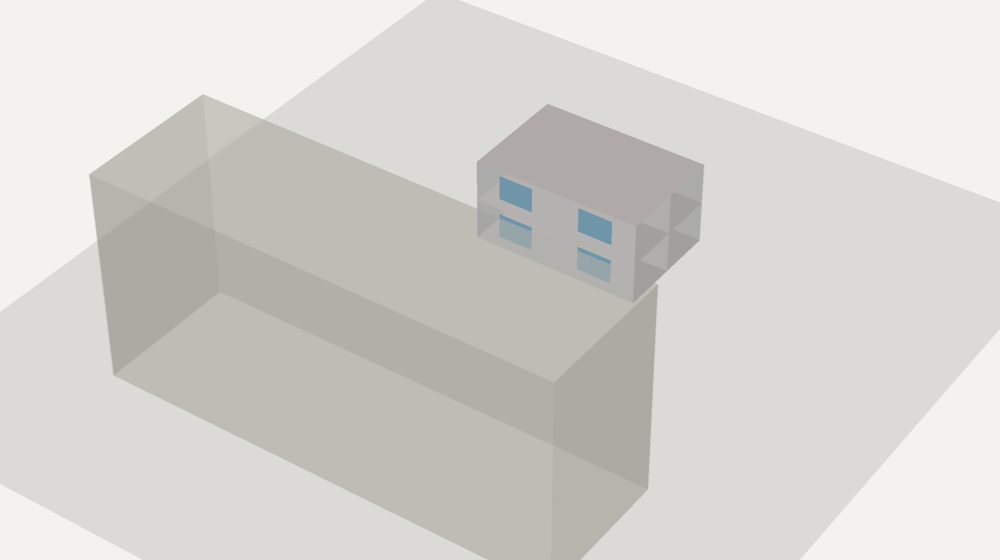

In [3]:
pl = v3.plotter(size=(1000, 560))
v3.add_ground(pl, (X0 - 15, X0 + W + 15, Y0 - 30, Y0 + D + 10), pad=5)
v3.add_meshes(pl, v3.mesh_from_dicts(neighbour), opacity=0.35)
v3.add_meshes(pl, v3.mesh_from_dicts(walls), color="#f5f5f4", opacity=0.6)
v3.add_meshes(pl, v3.mesh_from_dicts(slabs), color="#a8a29e")
v3.add_meshes(pl, v3.mesh_from_dicts(windows), color="#0284c7")
Image(v3.finish(pl, OUT / "06_model.png", azimuth=35, elevation=38, zoom=2.4, focus=(X0 + W / 2, Y0 - 6, 3)))

**What you see:** the building with its large south windows (blue) and the slabs. The neighbour
block in front (to the south) and the walls are drawn half transparent.

## 3. Daylight factor

The daylight factor is the share of the outdoor light (CIE overcast sky) that reaches a point
inside, in %. It needs no weather and no time. The SDK puts a sensor grid on each floor
(`grid_size` 0.5 m, 0.8 m above the floor). A common target is 2 % or more.

In [4]:
daylight = DaylightFactorModelRequest(
    analysis_type=AnalysesName.daylight_factor,
    barriers=barriers, openings=openings, spatial_volumes=spaces,
    floors=[0, 1], context_geometry=context, grid_size=0.5,
)
preview = client.analyses.preview_parts(daylight)
print(f"{preview.total_sensors} sensors, jobs {preview.part_count}, cost {preview.estimated_cost_tokens} tokens")

768 sensors, jobs 1, cost 10 tokens


In [5]:
df = client.analyses.run_and_wait(daylight)
rooms_table = pd.DataFrame(df.rooms).set_index("name")[["mean_df", "median_df", "area_pct_df_ge_2", "window_area"]]
rooms_table.columns = ["mean DF %", "median DF %", "area with DF >= 2 %", "window m²"]
rooms_table.style.format(precision=1)

,mean DF %,median DF %,area with DF >= 2 %,window m²
name,,,,
F0 south,3.0,1.1,34.4,9.0
F0 north,1.8,0.8,16.7,2.9
F1 south,3.4,1.2,37.0,9.0
F1 north,1.8,0.8,16.7,2.9


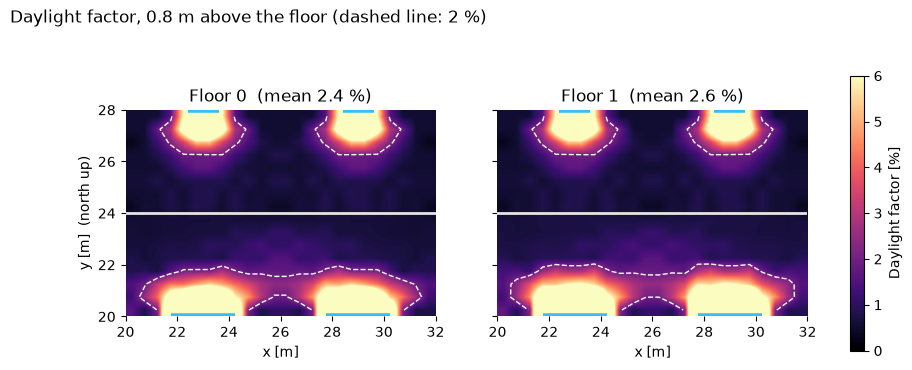

In [6]:
cols = df.columns  # one row for each sensor: x, y, z, values, room
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, (g, group) in zip(axes, enumerate(df.groups)):
    s = slice(cols.group_offsets[g], cols.group_offsets[g + 1])
    x, y, v = cols.x[s], cols.y[s], cols.values[s]
    xs, ys = np.unique(x), np.unique(y)
    grid = np.full((len(ys), len(xs)), np.nan)
    grid[np.searchsorted(ys, y), np.searchsorted(xs, x)] = v
    im = ax.imshow(grid, origin="lower", cmap="magma", vmin=0, vmax=6, interpolation="bilinear",
                   extent=(xs[0] - 0.25, xs[-1] + 0.25, ys[0] - 0.25, ys[-1] + 0.25))
    ax.contour(xs, ys, grid, levels=[2], colors="white", linewidths=1, linestyles="--")
    for name, wmesh in windows.items():  # windows as blue lines on the plan
        p = np.reshape(wmesh["coordinates"], (-1, 3))
        if name.endswith(f"-{g}0") or name.endswith(f"-{g}1"):
            ax.plot(p[:2, 0], p[:2, 1], color="#38bdf8", lw=4, solid_capstyle="butt")
    ax.plot([X0, X0 + W], [Y0 + D / 2] * 2, color="#e7e5e4", lw=2)  # wall between the rooms
    ax.set(title=f"Floor {g}  (mean {group['mean_df']:.1f} %)", aspect="equal", xlabel="x [m]")
    ax.set_frame_on(False)
axes[0].set_ylabel("y [m]  (north up)")
fig.colorbar(im, ax=axes, shrink=0.85, label="Daylight factor [%]")
fig.suptitle("Daylight factor, 0.8 m above the floor (dashed line: 2 %)", x=0.02, ha="left")
plt.show()

**What you see:** the daylight is strong near the windows and falls off quickly into the room.
The south rooms are brighter than the north rooms: their windows are larger. The south room on
floor 0 is darker than the same room on floor 1, because the neighbour block hides more of the sky
from the lower windows.

## 4. Energy balance

The energy balance gives the monthly heating and cooling **need** of each room (zone), in kWh.
`from_weather` takes the weather from an EPW file. `solar_model="irradiance"` uses the shade
of the context geometry, and reads latitude and longitude from the EPW header.
The building properties use the server defaults; change them with `energy_settings=EnergySettings(...)`.

In [7]:
weather = parse_epw(site.fetch_epw())  # Vienna TMYx, downloaded once into ./cache
energy_request = EnergyBalanceModelRequest.from_weather(
    weather, solar_model="irradiance",
    spatial_volumes=spaces, barriers=barriers, openings=openings, context_geometry=context,
)
preview = client.analyses.preview_parts(energy_request)
print(f"jobs {preview.part_count}, cost {preview.estimated_cost_tokens} tokens")

jobs 1, cost 10 tokens


In [8]:
energy = client.analyses.run_and_wait(energy_request)
zones = energy["output"]
annual = pd.DataFrame(
    {z["zone_name"]: {"floor m²": z["floor_area_m2"], "heating kWh/m²·yr": z["annual"]["EUI_heat"],
                      "cooling kWh/m²·yr": z["annual"]["EUI_cool"]} for z in zones}
).T.sort_index()
annual.style.format(precision=1)

,floor m²,heating kWh/m²·yr,cooling kWh/m²·yr
F0 north,48.0,63.7,2.1
F0 south,48.0,70.3,3.6
F1 north,48.0,72.6,4.2
F1 south,48.0,79.4,6.2


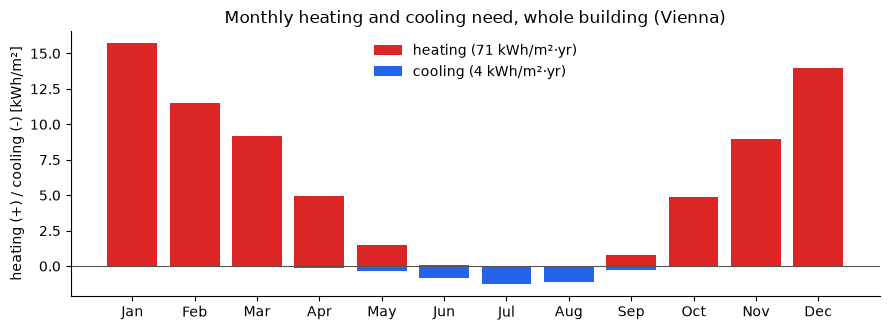

In [9]:
area = sum(z["floor_area_m2"] for z in zones)
heat = np.sum([[m["Q_heat_kWh"] for m in z["monthly"]] for z in zones], axis=0) / area
cool = np.sum([[m["Q_cool_kWh"] for m in z["monthly"]] for z in zones], axis=0) / area
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(months, heat, color="#dc2626", label=f"heating ({heat.sum():.0f} kWh/m²·yr)")
ax.bar(months, -cool, color="#2563eb", label=f"cooling ({cool.sum():.0f} kWh/m²·yr)")
ax.axhline(0, color="#57534e", lw=0.8)
ax.set(ylabel="heating (+) / cooling (-) [kWh/m²]", title="Monthly heating and cooling need, whole building (Vienna)")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()

**What you see:** heating (up) from October to April, cooling (down) in summer. This is the
energy **need** of the rooms, not the delivered energy: no boiler, heat pump or chiller is in it.

## Next steps

- Set U-values, glazing and set-points with `energy_settings=EnergySettings(...)`, and office
  hours with `operation=Operation.intermittent(hours=(8, 18), days="weekdays")`.
- Keep one building whole in one energy request: a slab between two heated rooms is internal.
- For your own sensor points or a horizontal surface (for example, a roof), use `sensor_points`
  or `sensor_surfaces` instead of `floors`.